# IEE 575 — Conditioning and Closure Properties
# ✅ SOLUTION NOTEBOOK

**Goal:** Build the mathematical machinery needed for Gaussian Process regression.

**Structure:**
1. Matrix operations with Gaussians
2. Closure properties
3. Conditioning mechanics
4. Geometric intuition

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

np.random.seed(42)
n_samples = 10000

---
# Part 1: Matrix Operations with Gaussians

## Exercise 1: Scalar Multiplication

**Setup:** $X \sim \mathcal{N}(0, 1)$, $Y = 3X$.

**Prediction answers:**
- Mean of Y = **0** (since $a \cdot \mu = 3 \cdot 0 = 0$)
- Variance of Y = **9** (since $a^2 \cdot \sigma^2 = 9 \cdot 1 = 9$)

Sample mean of Y:     -0.006  (theoretical: 0.0)
Sample variance of Y: 9.062  (theoretical: 9.0)


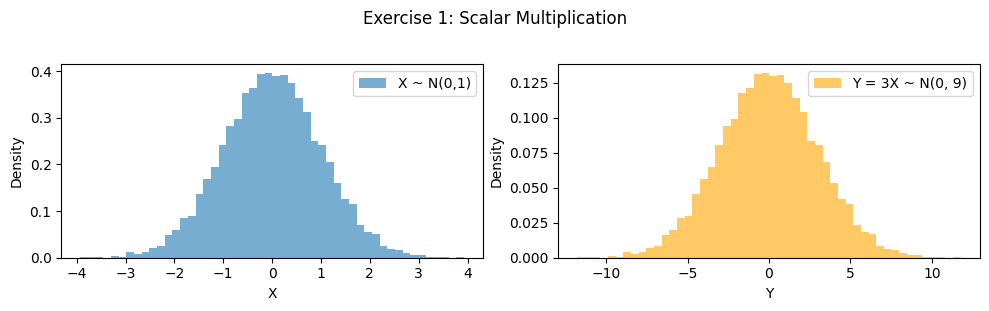

In [5]:
# Exercise 1 — Scalar Multiplication

X = np.random.randn(n_samples)   # X ~ N(0, 1)

a = 3
Y = a * X

print(f"Sample mean of Y:     {Y.mean():.3f}  (theoretical: {a * 0:.1f})")
print(f"Sample variance of Y: {Y.var():.3f}  (theoretical: {a**2 * 1:.1f})")

fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].hist(X, bins=50, density=True, alpha=0.6, label='X ~ N(0,1)')
ax[0].set_xlabel('X'); ax[0].set_ylabel('Density'); ax[0].legend()

ax[1].hist(Y, bins=50, density=True, alpha=0.6, color='orange', label=f'Y = {a}X ~ N(0, {a**2})')
ax[1].set_xlabel('Y'); ax[1].set_ylabel('Density'); ax[1].legend()

plt.suptitle('Exercise 1: Scalar Multiplication', y=1.02)
plt.tight_layout()
plt.show()

**Explanation:** Variance scales by $a^2$ (not $a$) because variance is defined as $\mathbb{E}[(Y - \mu_Y)^2]$. When $Y = aX$, the deviation $(Y - \mu_Y) = a(X - \mu_X)$, and squaring introduces $a^2$. Scaling stretches the distribution, so spread grows proportionally to $|a|$ — but variance, being the *squared* spread, grows by $a^2$.

---
## Exercise 2: Affine Transformation

**Setup:** $X \sim \mathcal{N}(2, 4)$, $Y = -2X + 5$.

**Prediction answers:**
- Mean of Y = $-2 \cdot 2 + 5 = \mathbf{1}$
- Variance of Y = $(-2)^2 \cdot 4 = \mathbf{16}$

Sample mean of Y:     0.946  (theoretical: 1)
Sample variance of Y: 16.031  (theoretical: 16)


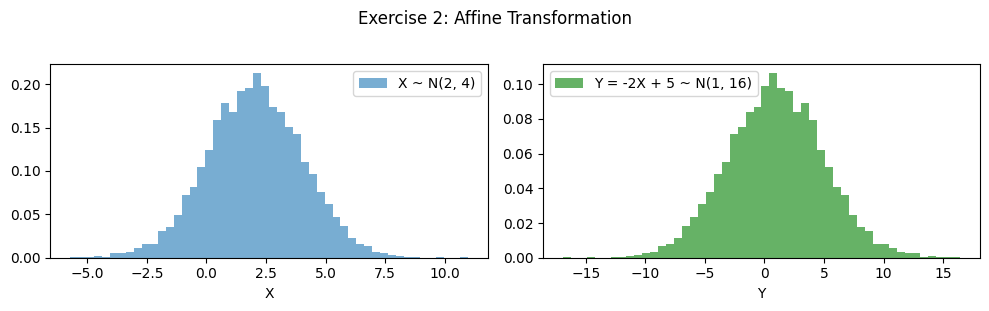

In [6]:
# Exercise 2 — Affine Transformation

mu_X, sigma2_X = 2, 4
X = np.random.randn(n_samples) * np.sqrt(sigma2_X) + mu_X   # X ~ N(2, 4)

a, b = -2, 5
Y = a * X + b

theoretical_mean = a * mu_X + b
theoretical_var  = a**2 * sigma2_X

print(f"Sample mean of Y:     {Y.mean():.3f}  (theoretical: {theoretical_mean})")
print(f"Sample variance of Y: {Y.var():.3f}  (theoretical: {theoretical_var})")

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(X, bins=50, density=True, alpha=0.6, label='X ~ N(2, 4)')
ax[0].set_xlabel('X'); ax[0].legend()
ax[1].hist(Y, bins=50, density=True, alpha=0.6, color='green',
           label=f'Y = {a}X + {b} ~ N({theoretical_mean}, {theoretical_var})')
ax[1].set_xlabel('Y'); ax[1].legend()
plt.suptitle('Exercise 2: Affine Transformation', y=1.02)
plt.tight_layout(); plt.show()

**Explanation:** Adding a constant $b$ shifts every sample by the same amount — the distribution slides left or right on the number line but its *shape* (and therefore its spread/variance) is unchanged. Variance measures dispersion *around the mean*, and that dispersion is unaffected by a rigid shift.

---
## Exercise 3: Matrix-Vector Multiplication

**Setup:** $\mathbf{X} \sim \mathcal{N}(\mathbf{0}, I)$, $Y = [2, 1]\mathbf{X}$.

**Prediction answers:**
- Mean of Y = $\mathbf{w}^T \boldsymbol{\mu} = [2,1][0,0]^T = \mathbf{0}$
- Variance of Y = $\mathbf{w}^T I \mathbf{w} = 4 + 1 = \mathbf{5}$

Sample mean of Y:     -0.025  (theoretical: 0)
Sample variance of Y: 5.051  (theoretical: 5)


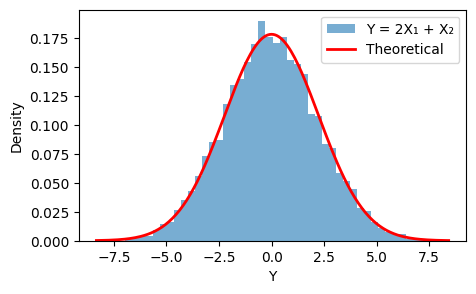

In [7]:
# Exercise 3 — Matrix-Vector Multiplication

mu    = np.array([0, 0])
Sigma = np.array([[1, 0],
                  [0, 1]])
w = np.array([2, 1])

X = np.random.multivariate_normal(mu, Sigma, size=n_samples)
Y = X @ w

theoretical_mean = w.T @ mu
theoretical_var  = w.T @ Sigma @ w

print(f"Sample mean of Y:     {Y.mean():.3f}  (theoretical: {theoretical_mean})")
print(f"Sample variance of Y: {Y.var():.3f}  (theoretical: {theoretical_var})")

plt.figure(figsize=(5, 3))
plt.hist(Y, bins=50, density=True, alpha=0.6, label='Y = 2X₁ + X₂')
y_range = np.linspace(Y.min(), Y.max(), 200)
plt.plot(y_range, norm.pdf(y_range, theoretical_mean, np.sqrt(theoretical_var)),
         'r-', lw=2, label='Theoretical')
plt.xlabel('Y'); plt.ylabel('Density'); plt.legend(); plt.show()

**Hand calculation:** $\mathbf{w}^T \Sigma \mathbf{w} = [2,1]\begin{bmatrix}1&0\\0&1\end{bmatrix}[2,1]^T = [2,1][2,1]^T = 4+1=5$. ✓

---
## Exercise 4: Correlated Case

**Prediction:** Variance will be **larger** because positive correlation means $X_1$ and $X_2$ tend to move together. When we add $2X_1 + X_2$, the positively correlated component amplifies fluctuations rather than cancelling them.

**Hand calculation:** $\mathbf{w}^T \Sigma \mathbf{w} = [2,1]\begin{bmatrix}1&0.7\\0.7&1\end{bmatrix}[2,1]^T = [2+0.7, 1.4+1][2,1]^T = [2.7, 2.4][2,1]^T = 5.4 + 2.4 = \mathbf{7.8}$

In [8]:
# Exercise 4 — Correlated Case

mu    = np.array([0, 0])
Sigma = np.array([[1,   0.7],
                  [0.7, 1  ]])
w = np.array([2, 1])

X = np.random.multivariate_normal(mu, Sigma, size=n_samples)
Y = X @ w

theoretical_var = w.T @ Sigma @ w

print(f"Sample variance of Y: {Y.var():.3f}")
print(f"Theoretical variance: {theoretical_var:.3f}")
print(f"Compare to Exercise 3 variance: 5.0")
print(f"Increase due to correlation: {theoretical_var - 5.0:.3f}")

Sample variance of Y: 7.761
Theoretical variance: 7.800
Compare to Exercise 3 variance: 5.0
Increase due to correlation: 2.800


**Explanation:** With positive correlation, when $X_1$ is large, $X_2$ also tends to be large. In $Y = 2X_1 + X_2$ both terms simultaneously inflate or deflate, amplifying the total variation. The off-diagonal terms in $\mathbf{w}^T\Sigma\mathbf{w}$ contribute $2 \cdot w_1 w_2 \cdot \Sigma_{12} = 2 \cdot 2 \cdot 1 \cdot 0.7 = 2.8$ extra variance.

---
# Part 2: Closure Properties

## Exercise 5: Sum of Independent Gaussians

**Prediction answers:**
- Mean of Z = $2 + (-1) = \mathbf{1}$
- Variance of Z = $3 + 2 = \mathbf{5}$
- Is Z Gaussian? **Yes** (closure under addition)

Sample mean:     1.018  (theoretical: 1)
Sample variance: 5.006  (theoretical: 5)


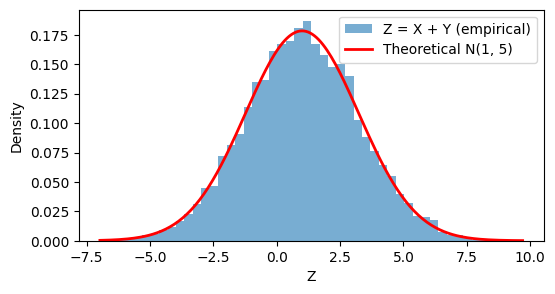

In [9]:
# Exercise 5 — Sum of Independent Gaussians

mu_X, sigma2_X = 2, 3
mu_Y, sigma2_Y = -1, 2

X = np.random.randn(n_samples) * np.sqrt(sigma2_X) + mu_X
Y = np.random.randn(n_samples) * np.sqrt(sigma2_Y) + mu_Y   # FILLED IN

Z = X + Y

theoretical_mean = mu_X + mu_Y
theoretical_var  = sigma2_X + sigma2_Y

print(f"Sample mean:     {Z.mean():.3f}  (theoretical: {theoretical_mean})")
print(f"Sample variance: {Z.var():.3f}  (theoretical: {theoretical_var})")

plt.figure(figsize=(6, 3))
plt.hist(Z, bins=50, density=True, alpha=0.6, label='Z = X + Y (empirical)')
z_range = np.linspace(Z.min(), Z.max(), 200)
plt.plot(z_range, norm.pdf(z_range, theoretical_mean, np.sqrt(theoretical_var)),
         'r-', lw=2, label=f'Theoretical N({theoretical_mean}, {theoretical_var})')
plt.xlabel('Z'); plt.ylabel('Density'); plt.legend(); plt.show()

**Explanation:** The histogram closely follows the theoretical Gaussian curve, confirming closure under addition. This matters because GP predictions are sums of Gaussian-weighted function evaluations — if Gaussians weren't closed under addition, the GP posterior couldn't be Gaussian.

---
## Exercise 6: Linear Combination with Correlation

**Setup:** $\mathbf{X} \sim \mathcal{N}([1,-1]^T, \begin{bmatrix}2&1\\1&3\end{bmatrix})$, $Z = 3X_1 - 2X_2$.

**Prediction answers:**
- Is Z Gaussian? **Yes**
- Mean of Z = $\mathbf{w}^T\boldsymbol{\mu} = [3,-2][1,-1]^T = 3 + 2 = \mathbf{5}$
- Variance: $[3,-2]\begin{bmatrix}2&1\\1&3\end{bmatrix}[3,-2]^T = [6-2, 3-6][3,-2]^T = [4,-3][3,-2]^T = 12+6 = \mathbf{18}$

Sample mean:     5.007  (theoretical: 5)
Sample variance: 17.635  (theoretical: 18)


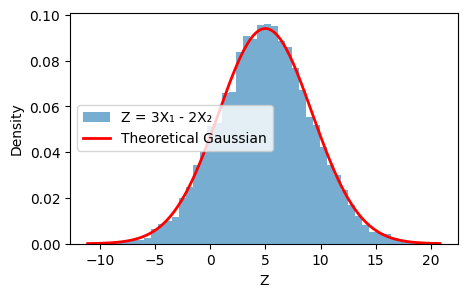

In [10]:
# Exercise 6 — Linear Combination with Correlation

mu    = np.array([1, -1])
Sigma = np.array([[2, 1],
                  [1, 3]])
w = np.array([3, -2])

X = np.random.multivariate_normal(mu, Sigma, size=n_samples)
Z = X @ w   # FILLED IN

theoretical_mean = w.T @ mu
theoretical_var  = w.T @ Sigma @ w

print(f"Sample mean:     {Z.mean():.3f}  (theoretical: {theoretical_mean})")
print(f"Sample variance: {Z.var():.3f}  (theoretical: {theoretical_var})")

plt.figure(figsize=(5, 3))
plt.hist(Z, bins=50, density=True, alpha=0.6, label='Z = 3X₁ - 2X₂')
z_range = np.linspace(Z.min(), Z.max(), 200)
plt.plot(z_range, norm.pdf(z_range, theoretical_mean, np.sqrt(theoretical_var)),
         'r-', lw=2, label='Theoretical Gaussian')
plt.xlabel('Z'); plt.ylabel('Density'); plt.legend(); plt.show()

**Why this matters for GPs:** A GP prediction at a new point $x^*$ is a linear combination of the joint Gaussian over all observed and unobserved points. Closure guarantees the posterior is still Gaussian — so we get a full predictive distribution (mean + variance), not just a point estimate.

---
# Part 3: Conditioning Mechanics

## Conditioning Formulas (reference)

$$\mu_{2|1} = \mu_2 + \Sigma_{21} \Sigma_{11}^{-1} (x_1 - \mu_1)$$
$$\Sigma_{2|1} = \Sigma_{22} - \Sigma_{21} \Sigma_{11}^{-1} \Sigma_{12}$$

## Exercise 7: Bivariate Conditioning

**Setup:** $\Sigma = \begin{bmatrix}1&0.8\\0.8&1\end{bmatrix}$, condition on $X_1 = 1.5$.

**Hand calculation:**
$$\mu_{2|1} = 0 + \frac{0.8}{1}(1.5 - 0) = \mathbf{1.2}$$
$$\Sigma_{2|1} = 1 - \frac{0.8 \cdot 0.8}{1} = 1 - 0.64 = \mathbf{0.36}$$

In [11]:
# Exercise 7 — Bivariate Conditioning

mu    = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.8],
                  [0.8, 1.0]])

mu1, mu2         = mu[0], mu[1]
S11, S12         = Sigma[0, 0], Sigma[0, 1]
S21, S22         = Sigma[1, 0], Sigma[1, 1]

x1_obs = 1.5

mu_cond    = mu2 + S21 / S11 * (x1_obs - mu1)   # FILLED IN
Sigma_cond = S22 - S21 / S11 * S12               # FILLED IN

print(f"Conditional mean:     {mu_cond:.3f}   (hand calc: 1.200)")
print(f"Conditional variance: {Sigma_cond:.3f}   (hand calc: 0.360)")
print(f"Conditional std dev:  {np.sqrt(Sigma_cond):.3f}")

Conditional mean:     1.200   (hand calc: 1.200)
Conditional variance: 0.360   (hand calc: 0.360)
Conditional std dev:  0.600


**Explanation:** Observing $X_1 = 1.5$ (above its mean of 0) shifts the mean of $X_2$ upward because the strong positive correlation ($\rho=0.8$) implies $X_2$ is likely to be above its own mean too. The shift is proportional to the deviation $(x_1 - \mu_1)$ scaled by $\Sigma_{21}/\Sigma_{11}$ — the "regression coefficient".

---
## Exercise 8: Effect of Correlation

**Prediction:**
- As $\rho$ increases, conditional mean will **increase** (stronger pull toward $X_1$'s deviation)
- As $\rho$ increases, conditional variance will **decrease** (more information from $X_1$)

In [12]:
# Exercise 8 — Effect of Correlation

rho_values = [0, 0.5, 0.9, 0.99]
x1_obs = 1.5

print(f"Conditioning on X1 = {x1_obs}\n")
print(f"{'ρ':<6} {'μ_2|1':<12} {'σ²_2|1':<12}")
print("-" * 32)

for rho in rho_values:
    S = np.array([[1, rho], [rho, 1]])
    mu_c  = 0 + S[1,0] / S[0,0] * (x1_obs - 0)   # FILLED IN
    sig_c = S[1,1] - S[1,0] / S[0,0] * S[0,1]     # FILLED IN
    print(f"{rho:<6} {mu_c:<12.3f} {sig_c:<12.4f}")

Conditioning on X1 = 1.5

ρ      μ_2|1        σ²_2|1      
--------------------------------
0      0.000        1.0000      
0.5    0.750        0.7500      
0.9    1.350        0.1900      
0.99   1.485        0.0199      


**Explanation:** As $\rho \to 1$, $X_1$ and $X_2$ become *almost the same variable*. Observing $X_1 = 1.5$ tells us $X_2 \approx 1.5$ with near certainty — conditional variance $\to 0$. The Schur complement $\Sigma_{22} - \Sigma_{21}\Sigma_{11}^{-1}\Sigma_{12} = 1 - \rho^2 \to 0$. At $\rho = 1$ the joint distribution degenerates onto a line; there is no residual uncertainty.

---
## Exercise 9: Multivariate Conditioning

**Prediction:**
- $\mu_{2|1,3}$: The competing effects are $X_1=1.0$ (positive, $\rho_{12}=0.7$) vs $X_3=-0.5$ (negative, $\rho_{23}=0.6$). $X_1$ wins on both magnitude and correlation, so the mean should be **slightly positive**.
- $\sigma^2_{2|1,3}$ will be **smaller** than the marginal variance of 1.0 (two observations reduce uncertainty more than one).

In [13]:
# Exercise 9 — Multivariate Conditioning

mu    = np.array([0., 0., 0.])
Sigma = np.array([[1.0, 0.7, 0.5],
                  [0.7, 1.0, 0.6],
                  [0.5, 0.6, 1.0]])

x_obs    = np.array([1.0, -0.5])   # X1 = 1.0, X3 = -0.5
obs_idx  = [0, 2]
pred_idx = [1]

mu_obs  = mu[obs_idx]
mu_pred = mu[pred_idx]

S_oo = Sigma[np.ix_(obs_idx,  obs_idx)]
S_po = Sigma[np.ix_(pred_idx, obs_idx)]
S_op = Sigma[np.ix_(obs_idx,  pred_idx)]
S_pp = Sigma[np.ix_(pred_idx, pred_idx)]

# Conditioning formulas (matrix version)   — FILLED IN
mu_cond    = mu_pred + S_po @ np.linalg.inv(S_oo) @ (x_obs - mu_obs)
Sigma_cond = S_pp    - S_po @ np.linalg.inv(S_oo) @ S_op

print(f"Conditioning on X1 = {x_obs[0]}, X3 = {x_obs[1]}")
print(f"\nConditional mean of X2:     {mu_cond[0]:.3f}")
print(f"Conditional variance of X2: {Sigma_cond[0,0]:.3f}")
print(f"\nMarginal variance of X2:    {Sigma[1,1]:.3f}")
print(f"Variance reduction:         {Sigma[1,1] - Sigma_cond[0,0]:.3f}")

Conditioning on X1 = 1.0, X3 = -0.5

Conditional mean of X2:     0.367
Conditional variance of X2: 0.427

Marginal variance of X2:    1.000
Variance reduction:         0.573


**Explanation:** $X_1=1.0$ pushes $X_2$ up (positive correlation 0.7), while $X_3=-0.5$ pulls $X_2$ down (positive correlation 0.6, but $X_3$ is negative). The net effect is a small positive mean. Observing *two* variables reduces variance more than one because each provides an independent "line of sight" toward $X_2$, and their information is partially non-redundant.

